In [18]:
! pip install numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# --------------------
# Tag 與 Anchor 初始化
# --------------------
anchors_position = []

# Anchor 設在 63x8 場地的 X 形狀
for i in range(100):
    anchors_position.append((i*0.08, i*0.08*63/8))
    anchors_position.append((i*0.08, 63 - i*0.08*63/8))
    anchors_position.append((i*0.08,63))
    anchors_position.append((0, 0.63*i))
    anchors_position.append((8, 0.63*i))
    anchors_position.append((4, 0.63*i))

anchors_position = np.array(anchors_position)


center_point = np.array([4, 0])  # 可改成 (4, 0) 等
ranges = [(0, 20), (20, 40), (40,90)]  # 多個距離區間

anchor_distances_to_center = np.linalg.norm(anchors_position - center_point, axis=1)


In [41]:
def two_tag_trilateration(tag_position, anchors_position, mean=0, std_dev=0.1, sliding_window=5): # 每 5 筆資料取一次平均
    
    anchor2tag_distance = {}
    anchor2tag_distance_noisy = {}

    for tag in tag_position:
        tag_arr = np.array(tag)
        distances = np.linalg.norm(anchors_position - tag_arr, axis=1)
        noise = np.zeros(distances.shape)
        for i in range(sliding_window if sliding_window > 0 else 1):
            noise += np.random.normal(loc=mean, scale=std_dev, size=distances.shape)
        # noise /= sliding_window  # 平均化噪音
        if sliding_window > 0:
            noise /= sliding_window  # 平均化噪音
        
        anchor2tag_distance[tag] = distances
        anchor2tag_distance_noisy[tag] = distances + noise

    # --------------------
    # 使用 trilateration 推估點位並畫圖
    # --------------------
    plt.figure(figsize=(8, 12))
    plt.title(f"Trilateration Position Error Visualization (Gaussian std = {std_dev})")
    plt.xlabel("X Coordinate (m)")
    plt.ylabel("Y Coordinate (m)")

    # 畫出 tag 與 anchor 位置
    for tag in tag_position:
        plt.scatter(*tag, color='red', label=f'Tag {tag}', s=60)

    plt.scatter(anchors_position[:, 0], anchors_position[:, 1], color='lightblue', label='Anchors', s=5)

    # --------------------
    # 用兩個 tag 進行 trilateration
    # --------------------
    tag_list = list(tag_position)
    a = np.linalg.norm(np.array(tag_list[0]) - np.array(tag_list[1]))  # tag 間距（8 公尺）

    errors = []

    for i in range(len(anchors_position)):
        b_noisy = anchor2tag_distance_noisy[tag_list[0]][i]
        c_noisy = anchor2tag_distance_noisy[tag_list[1]][i]

        b_true = anchor2tag_distance[tag_list[0]][i]
        c_true = anchor2tag_distance[tag_list[1]][i]

        # ➤ noisy 推估位置
        x = (a**2 - c_noisy**2 + b_noisy**2) / (2*a)
        y = np.sqrt(abs(b_noisy**2 - x**2))

        # ➤ 真實位置（沒有 noise）
        x_c = (a**2 - c_true**2 + b_true**2) / (2*a)
        y_c = np.sqrt(abs(b_true**2 - x_c**2))

        # ➤ 誤差分析
        error = np.sqrt((x - x_c)**2 + (y - y_c)**2)
        errors.append(error)

        # ➤ 畫圖
        plt.scatter(x, y, color='green', s=10)    # noisy estimate
        plt.scatter(x_c, y_c, color='blue', s=10) # ground truth
        plt.arrow(x_c, y_c, x - x_c, y - y_c, color='gray', width=0.005, alpha=0.4, length_includes_head=True)

    # --------------------
    # 圖例與誤差統計
    # --------------------
    plt.legend()
    errors = np.array(errors)
    print(f"✅ Total points: {len(errors)}")
    print(f"📊 Mean error     = {np.mean(errors):.4f} m")
    print(f"📈 Max error      = {np.max(errors):.4f} m")
    print(f"📉 Std deviation  = {np.std(errors):.4f} m")

    # --------------------
    # 畫出誤差分布直方圖
    # --------------------
    plt.figure()
    plt.hist(errors, bins=30, color='purple', edgecolor='black')
    plt.title("Position Error Distribution")
    plt.xlabel("Error (m)")
    plt.ylabel("Frequency")



    # -----------------------------
    # 分析：anchor 與某點距離區間下的 error 分布
    # -----------------------------

    for r_min, r_max in ranges:
        indices = np.where((anchor_distances_to_center >= r_min) & (anchor_distances_to_center < r_max))[0]
        if len(indices) == 0:
            print(f"\n⛔ 距離範圍 {r_min}-{r_max} m 沒有 anchor 被選中")
            continue

        range_errors = errors[indices]

        print(f"\n📌 Anchor 與點 {tuple(center_point)} 距離在 [{r_min}, {r_max}) m 的情況")
        print(f"  數量: {len(indices)}")
        print(f"  ➤ 平均誤差: {np.mean(range_errors):.4f} m")
        print(f"  ➤ 最大誤差: {np.max(range_errors):.4f} m")
        print(f"  ➤ 誤差標準差: {np.std(range_errors):.4f} m")

        # 畫直方圖
        plt.figure()
        plt.hist(range_errors, bins=20, color='orange', edgecolor='black')
        plt.title(f"Error Distribution for Anchor Distance in [{r_min}, {r_max}) m to {tuple(center_point)}")
        plt.xlabel("Error (m)")
        plt.ylabel("Frequency")


    plt.show()


✅ Total points: 600
📊 Mean error     = 0.5136 m
📈 Max error      = 2.8003 m
📉 Std deviation  = 0.4752 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [0, 20) m 的情況
  數量: 159
  ➤ 平均誤差: 0.1993 m
  ➤ 最大誤差: 0.8204 m
  ➤ 誤差標準差: 0.1529 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [20, 40) m 的情況
  數量: 160
  ➤ 平均誤差: 0.4109 m
  ➤ 最大誤差: 1.5485 m
  ➤ 誤差標準差: 0.3127 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [40, 90) m 的情況
  數量: 281
  ➤ 平均誤差: 0.7498 m
  ➤ 最大誤差: 2.8003 m
  ➤ 誤差標準差: 0.5437 m


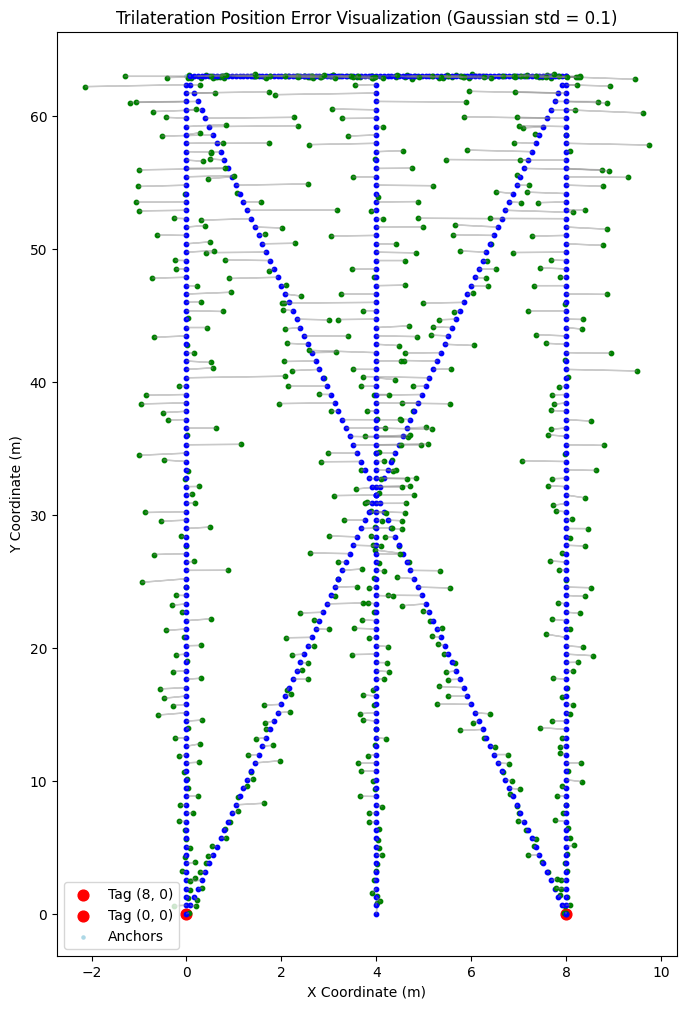

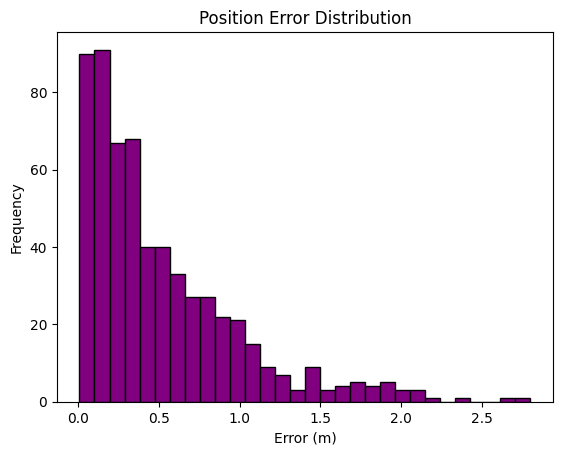

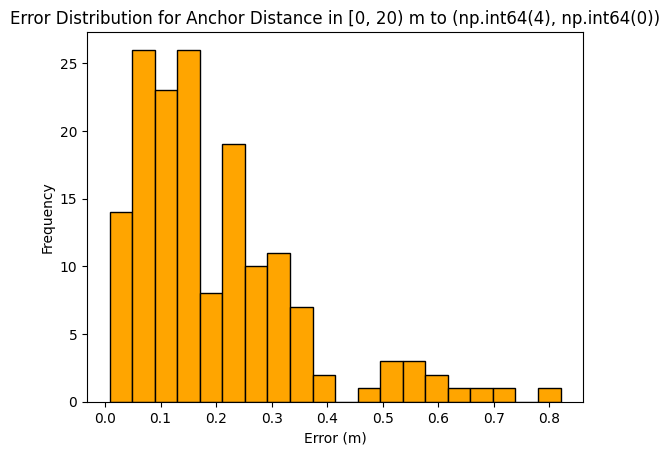

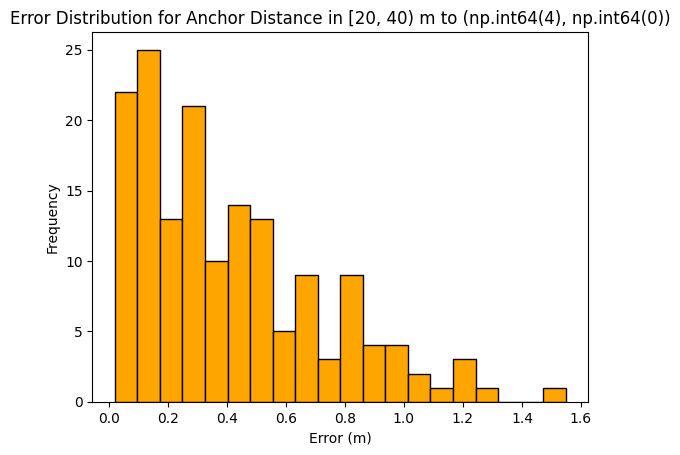

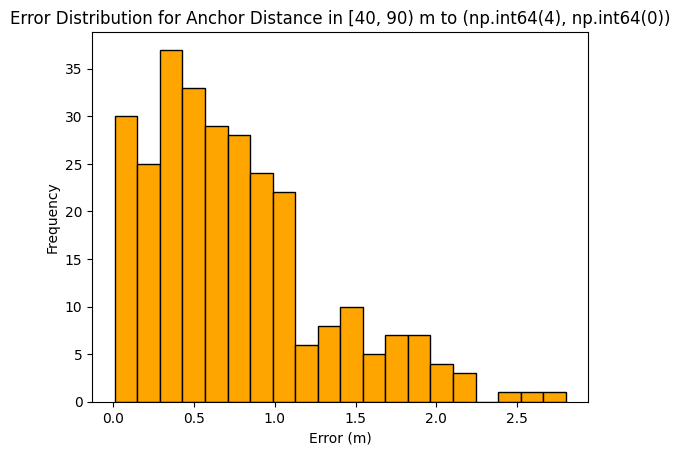

In [42]:
mean = 0
std_dev = 0.1
tag_position = {(0, 0), (8, 0)}  # 支援兩個 tag trilateration
two_tag_trilateration(tag_position, anchors_position, mean, std_dev, sliding_window=0)

✅ Total points: 600
📊 Mean error     = 0.2471 m
📈 Max error      = 1.3438 m
📉 Std deviation  = 0.2343 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [0, 20) m 的情況
  數量: 159
  ➤ 平均誤差: 0.0903 m
  ➤ 最大誤差: 0.5102 m
  ➤ 誤差標準差: 0.0794 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [20, 40) m 的情況
  數量: 160
  ➤ 平均誤差: 0.2052 m
  ➤ 最大誤差: 0.7175 m
  ➤ 誤差標準差: 0.1505 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [40, 90) m 的情況
  數量: 281
  ➤ 平均誤差: 0.3597 m
  ➤ 最大誤差: 1.3438 m
  ➤ 誤差標準差: 0.2705 m


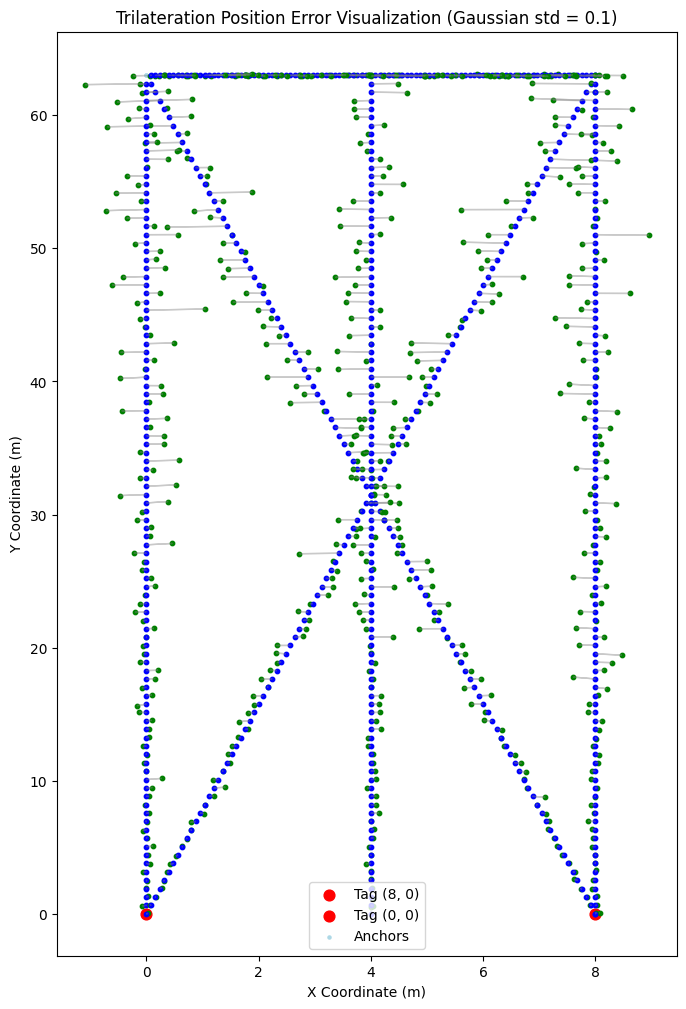

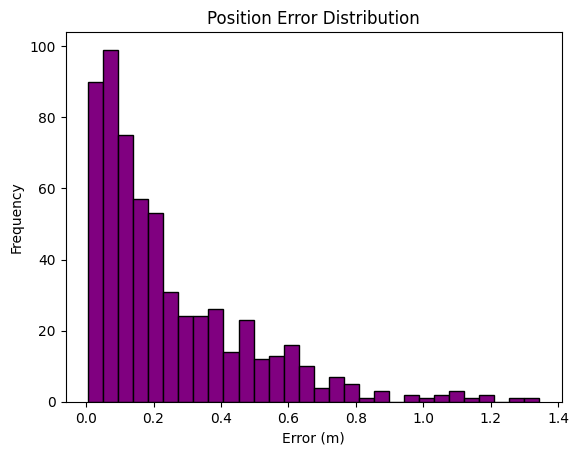

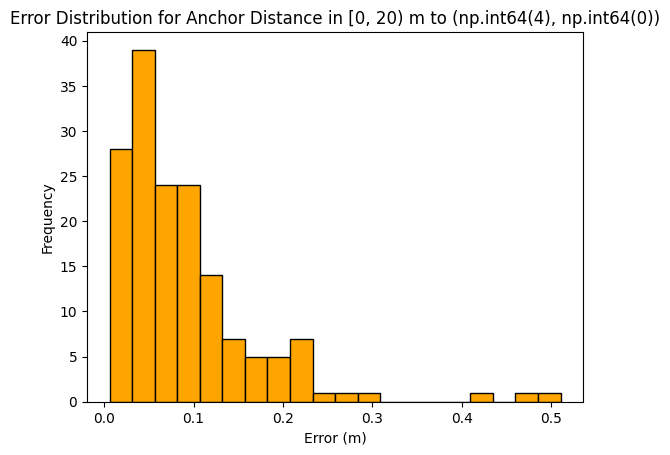

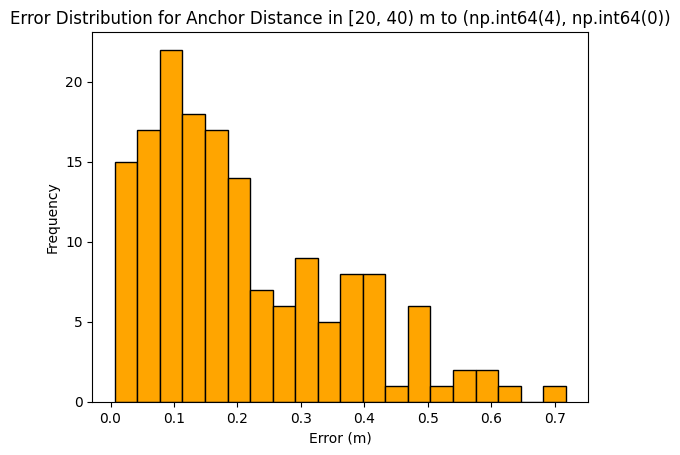

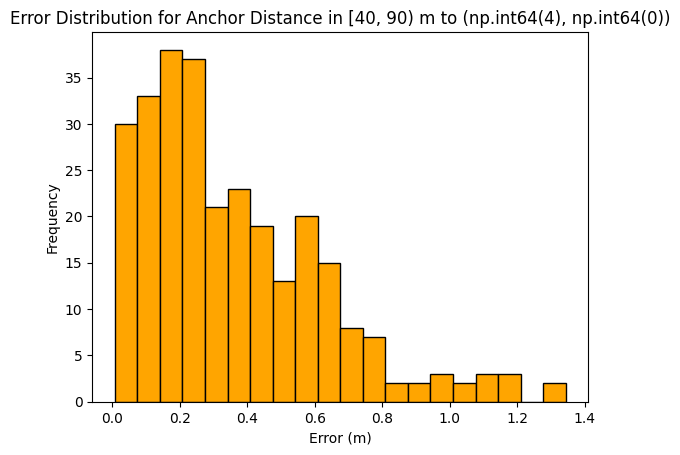

In [43]:
two_tag_trilateration(tag_position, anchors_position, mean, std_dev=0.1, sliding_window=5) 

✅ Total points: 600
📊 Mean error     = 1.0992 m
📈 Max error      = 5.9206 m
📉 Std deviation  = 1.0389 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [0, 20) m 的情況
  數量: 159
  ➤ 平均誤差: 0.3953 m
  ➤ 最大誤差: 1.2610 m
  ➤ 誤差標準差: 0.2746 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [20, 40) m 的情況
  數量: 160
  ➤ 平均誤差: 0.8923 m
  ➤ 最大誤差: 3.9303 m
  ➤ 誤差標準差: 0.7205 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [40, 90) m 的情況
  數量: 281
  ➤ 平均誤差: 1.6152 m
  ➤ 最大誤差: 5.9206 m
  ➤ 誤差標準差: 1.1813 m


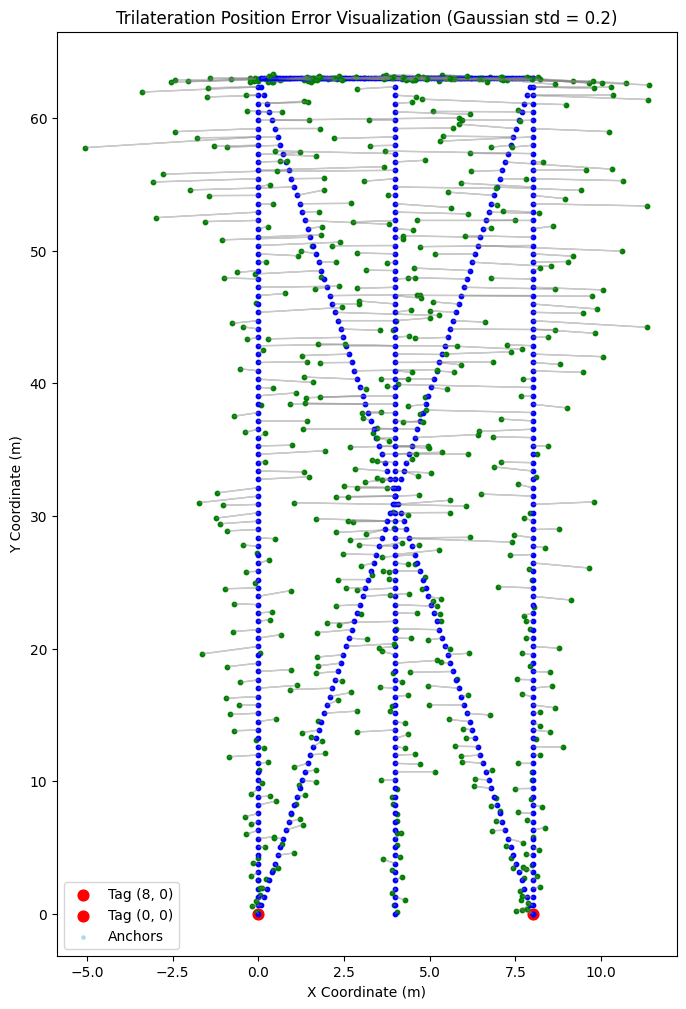

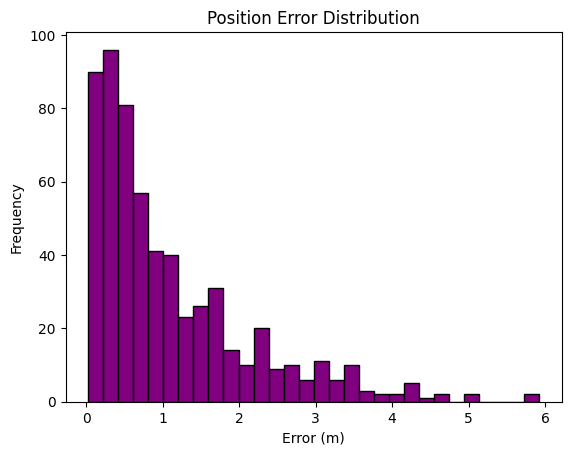

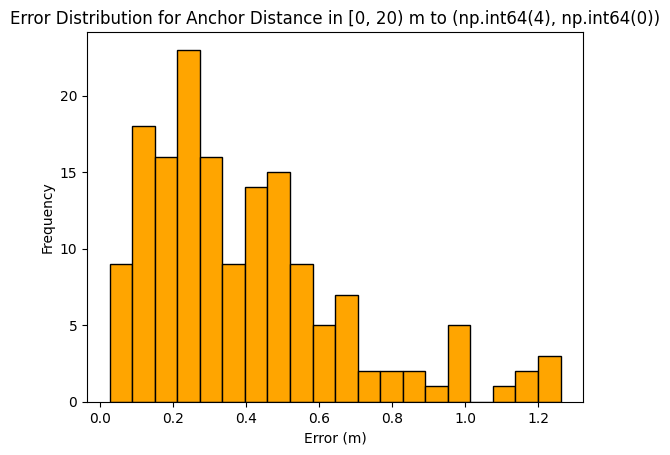

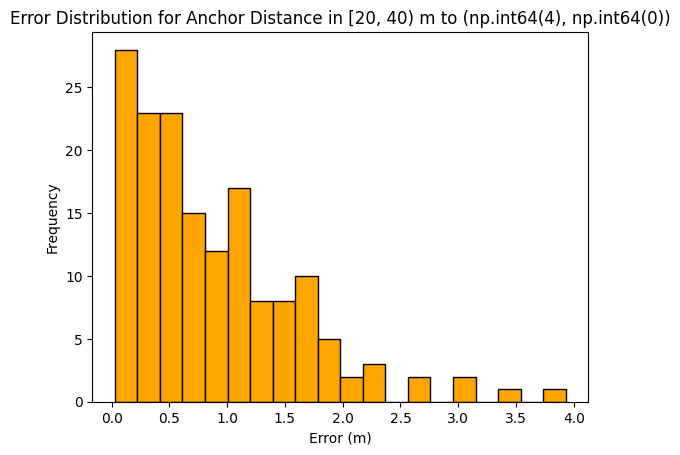

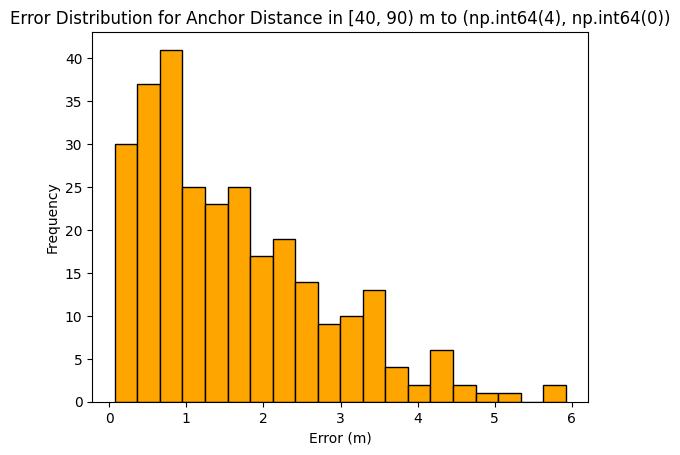

In [21]:
# --------------------
# 加入 Gaussian Noise
# --------------------
mean = 0
std_dev = 0.2
anchor2tag_distance = {}
anchor2tag_distance_noisy = {}

for tag in tag_position:
    tag_arr = np.array(tag)
    distances = np.linalg.norm(anchors_position - tag_arr, axis=1)
    noise = np.random.normal(loc=mean, scale=std_dev, size=distances.shape)
    anchor2tag_distance[tag] = distances
    anchor2tag_distance_noisy[tag] = distances + noise

# --------------------
# 使用 trilateration 推估點位並畫圖
# --------------------
plt.figure(figsize=(8, 12))
plt.title(f"Trilateration Position Error Visualization (Gaussian std = {std_dev})")
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")

# 畫出 tag 與 anchor 位置
for tag in tag_position:
    plt.scatter(*tag, color='red', label=f'Tag {tag}', s=60)

plt.scatter(anchors_position[:, 0], anchors_position[:, 1], color='lightblue', label='Anchors', s=5)

# --------------------
# 用兩個 tag 進行 trilateration
# --------------------
tag_list = list(tag_position)
a = np.linalg.norm(np.array(tag_list[0]) - np.array(tag_list[1]))  # tag 間距（8 公尺）

errors = []

for i in range(len(anchors_position)):
    b_noisy = anchor2tag_distance_noisy[tag_list[0]][i]
    c_noisy = anchor2tag_distance_noisy[tag_list[1]][i]

    b_true = anchor2tag_distance[tag_list[0]][i]
    c_true = anchor2tag_distance[tag_list[1]][i]

    # ➤ noisy 推估位置
    x = (a**2 - c_noisy**2 + b_noisy**2) / (2*a)
    y = np.sqrt(abs(b_noisy**2 - x**2))

    # ➤ 真實位置（沒有 noise）
    x_c = (a**2 - c_true**2 + b_true**2) / (2*a)
    y_c = np.sqrt(abs(b_true**2 - x_c**2))

    # ➤ 誤差分析
    error = np.sqrt((x - x_c)**2 + (y - y_c)**2)
    errors.append(error)

    # ➤ 畫圖
    plt.scatter(x, y, color='green', s=10)    # noisy estimate
    plt.scatter(x_c, y_c, color='blue', s=10) # ground truth
    plt.arrow(x_c, y_c, x - x_c, y - y_c, color='gray', width=0.005, alpha=0.4, length_includes_head=True)

# --------------------
# 圖例與誤差統計
# --------------------
plt.legend()
errors = np.array(errors)
print(f"✅ Total points: {len(errors)}")
print(f"📊 Mean error     = {np.mean(errors):.4f} m")
print(f"📈 Max error      = {np.max(errors):.4f} m")
print(f"📉 Std deviation  = {np.std(errors):.4f} m")

# --------------------
# 畫出誤差分布直方圖
# --------------------
plt.figure()
plt.hist(errors, bins=30, color='purple', edgecolor='black')
plt.title("Position Error Distribution")
plt.xlabel("Error (m)")
plt.ylabel("Frequency")



# -----------------------------
# 分析：anchor 與某點距離區間下的 error 分布
# -----------------------------

center_point = np.array([4, 0])  # 可改成 (4, 0) 等
ranges = [(0, 20), (20, 40), (40,90)]  # 多個距離區間

anchor_distances_to_center = np.linalg.norm(anchors_position - center_point, axis=1)

for r_min, r_max in ranges:
    indices = np.where((anchor_distances_to_center >= r_min) & (anchor_distances_to_center < r_max))[0]
    if len(indices) == 0:
        print(f"\n⛔ 距離範圍 {r_min}-{r_max} m 沒有 anchor 被選中")
        continue

    range_errors = errors[indices]

    print(f"\n📌 Anchor 與點 {tuple(center_point)} 距離在 [{r_min}, {r_max}) m 的情況")
    print(f"  數量: {len(indices)}")
    print(f"  ➤ 平均誤差: {np.mean(range_errors):.4f} m")
    print(f"  ➤ 最大誤差: {np.max(range_errors):.4f} m")
    print(f"  ➤ 誤差標準差: {np.std(range_errors):.4f} m")

    # 畫直方圖
    plt.figure()
    plt.hist(range_errors, bins=20, color='orange', edgecolor='black')
    plt.title(f"Error Distribution for Anchor Distance in [{r_min}, {r_max}) m to {tuple(center_point)}")
    plt.xlabel("Error (m)")
    plt.ylabel("Frequency")


plt.show()


In [ ]:


tag_position = {(0, 0), (0, -5), (8, 0)}  # 三個 tag
# tag_position = {(0, 0),  (8, 0)}

mean = 0
std_dev = 0.1
anchor2tag_distance = {}
anchor2tag_distance_noisy = {}



# --------------------
# 新增：ESP32三點定位演算法 (Python版)
# --------------------
def error_function(x, anchors, distances):
    error = 0.0
    for i in range(len(anchors)):
        dist = np.linalg.norm(x - anchors[i])
        error += (dist - distances[i]) ** 2
    return error

def gps_solve(anchors, distances, initial_guess=np.zeros(2), tol=1e-4, max_iter=200):
    x = initial_guess
    alpha = 0.01  # learning rate
    for _ in range(max_iter):
        grad = np.zeros(2)
        h = 1e-6
        for d in range(2):
            x1 = np.copy(x)
            x2 = np.copy(x)
            x1[d] += h
            x2[d] -= h
            grad[d] = (error_function(x1, anchors, distances) - error_function(x2, anchors, distances)) / (2 * h)
        x_new = x - alpha * grad
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x


# --------------------
# 使用 ESP32 三點演算法做 trilateration 模擬
# --------------------
tag_list = list(tag_position)
true_positions = []
est_positions = []
errors_gps = []

from itertools import product


#----- 距離點模擬： grid_points --------
# 設定場地範圍與密度
# ----------- 替代 grid_points 的生成方式（模仿 anchor 排列） -----------
grid_points = []

# 斜線部分：對角線與反對角線
for i in range(100):
    x = i * 0.08
    y_diag = x * (63 / 8)          # 對角線
    grid_points.append((x, y_diag))

# 水平線上緣
for i in range(100):
    x = 8 - i * 0.08
    grid_points.append((x, 63))

# 斜線部分：對角線與反對角線
for i in range(100):
    x = i * 0.08
    y_anti = 63 - x * (63 / 8)     # 反對角線
    grid_points.append((x, y_anti))

# 垂直線：左、中、右
for i in range(100):
    y = i * 0.63
    grid_points.append((8, y))
# 水平線上緣
for i in range(100):
    x = 8 - i * 0.08
    grid_points.append((x, 63))

# 垂直線：左、中、右
for i in range(100):
    y =63 - i * 0.63
    grid_points.append((0, y))





#----- 距離點模擬： X shape --------
# 會造成很大的誤差，可能是因 gps_solve 的初始值是由上一個點的估計值決定
# 而 X 形狀的點的排序不是照著一直線排序
# grid_points = list(set([tuple(pt) for pt in anchors_position]))



plt.figure(figsize=(8, 12))
plt.title(f"Multilateration Using {len(tag_list)} Tags, std_dev = {std_dev}")
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")

errors = []
prev_est = np.array([4.0, 0])  # 或 (0,0) 看你場地範圍

for point in grid_points:
    point_vec = np.array(point)
    
    # simulate distance from this unknown point to 3 tags
    anchors = [np.array(p) for p in tag_position]
    true_distances = [np.linalg.norm(point_vec - tag) for tag in anchors]
    
    # add gaussian noise
    noisy_distances = [d + np.random.normal(0, 0.2) for d in true_distances]
    
    # estimate this point using gps_solve
     # 使用上一次的結果作為初始值
    est = gps_solve(anchors, noisy_distances) #, initial_guess=prev_est
    prev_est = est.copy()  # 儲存這次結果作為下一次的初始值
    error = np.linalg.norm(est - point_vec)
    errors.append(error)
    
    # 畫點與誤差向量
    plt.scatter(est[0], est[1], color='green', s=4)
    plt.scatter(point_vec[0], point_vec[1], color='blue', s=4)
    plt.arrow(point_vec[0], point_vec[1], est[0]-point_vec[0], est[1]-point_vec[1], 
              color='gray', width=0.002, alpha=0.3, length_includes_head=True)

# 畫出 tag 位置
for tag in tag_position:
    plt.scatter(*tag, color='red', s=60, label=f'Tag {tag}')

plt.legend()
plt.show()

errors = np.array(errors)
print(f"Multilateration Using {len(tag_list)} Tags, std_dev = {std_dev}")
print(f"\n✅ Total Points: {len(errors)}")
print(f"📊 Mean Error     = {np.mean(errors):.4f} m")
print(f"📈 Max Error      = {np.max(errors):.4f} m")
print(f"📉 Std Deviation  = {np.std(errors):.4f} m")




for r_min, r_max in ranges:
    indices = np.where((anchor_distances_to_center >= r_min) & (anchor_distances_to_center < r_max))[0]
    if len(indices) == 0:
        print(f"\n⛔ 距離範圍 {r_min}-{r_max} m 沒有 anchor 被選中")
        continue

    range_errors = errors[indices]

    print(f"\n📌 Anchor 與點 {tuple(center_point)} 距離在 [{r_min}, {r_max}) m 的情況")
    print(f"  數量: {len(indices)}")
    print(f"  ➤ 平均誤差: {np.mean(range_errors):.4f} m")
    print(f"  ➤ 最大誤差: {np.max(range_errors):.4f} m")
    print(f"  ➤ 誤差標準差: {np.std(range_errors):.4f} m")


SyntaxError: invalid syntax (374172827.py, line 118)

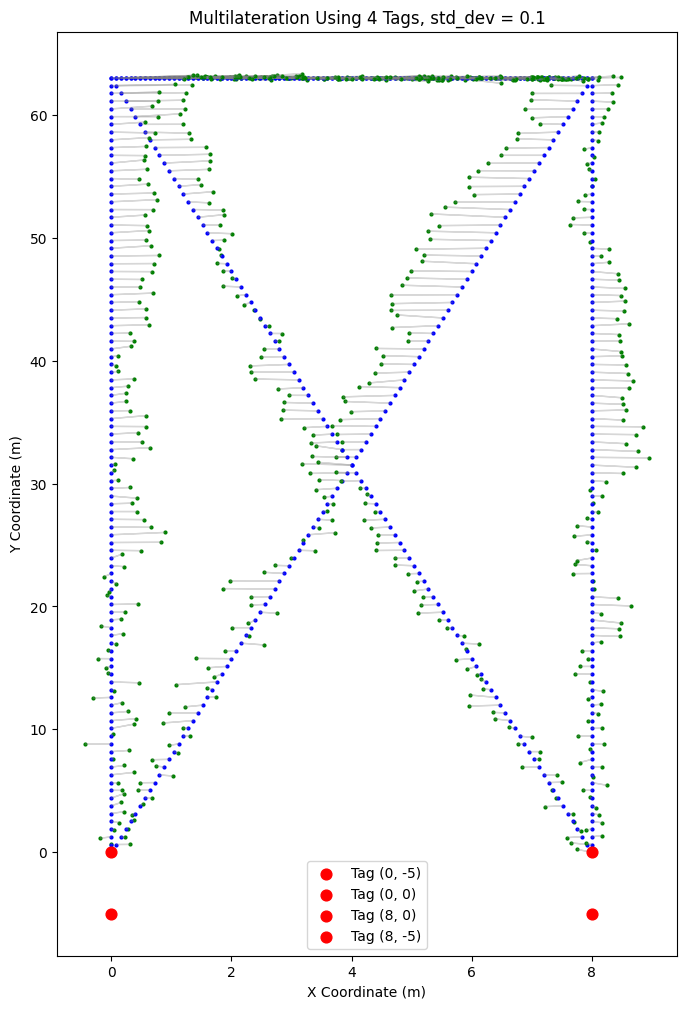


✅ Total Points: 600
📊 Mean Error     = 0.5718 m
📈 Max Error      = 1.4413 m
📉 Std Deviation  = 0.3645 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [0, 20) m 的情況
  數量: 159
  ➤ 平均誤差: 0.6808 m
  ➤ 最大誤差: 1.3285 m
  ➤ 誤差標準差: 0.3278 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [20, 40) m 的情況
  數量: 160
  ➤ 平均誤差: 0.3646 m
  ➤ 最大誤差: 1.2614 m
  ➤ 誤差標準差: 0.2713 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [40, 90) m 的情況
  數量: 281
  ➤ 平均誤差: 0.6281 m
  ➤ 最大誤差: 1.4413 m
  ➤ 誤差標準差: 0.3829 m


In [ ]:


tag_position = {(0, 0), (0, -5), (8, 0), (8, -5)}  
# tag_position = {(0, 0),  (8, 0)}

mean = 0
std_dev = 0.1
anchor2tag_distance = {}
anchor2tag_distance_noisy = {}



# --------------------
# 新增：ESP32三點定位演算法 (Python版)
# --------------------
def error_function(x, anchors, distances):
    error = 0.0
    for i in range(len(anchors)):
        dist = np.linalg.norm(x - anchors[i])
        error += (dist - distances[i]) ** 2
    return error

def gps_solve(anchors, distances, initial_guess=np.zeros(2), tol=1e-4, max_iter=200):
    x = initial_guess
    alpha = 0.01  # learning rate
    for _ in range(max_iter):
        grad = np.zeros(2)
        h = 1e-6
        for d in range(2):
            x1 = np.copy(x)
            x2 = np.copy(x)
            x1[d] += h
            x2[d] -= h
            grad[d] = (error_function(x1, anchors, distances) - error_function(x2, anchors, distances)) / (2 * h)
        x_new = x - alpha * grad
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x


# --------------------
# 使用 ESP32 三點演算法做 trilateration 模擬
# --------------------
tag_list = list(tag_position)
true_positions = []
est_positions = []
errors_gps = []

from itertools import product


#----- 距離點模擬： grid_points --------
# 設定場地範圍與密度
# ----------- 替代 grid_points 的生成方式（模仿 anchor 排列） -----------
grid_points = []

# 斜線部分：對角線與反對角線
for i in range(100):
    x = i * 0.08
    y_diag = x * (63 / 8)          # 對角線
    grid_points.append((x, y_diag))

# 水平線上緣
for i in range(100):
    x = 8 - i * 0.08
    grid_points.append((x, 63))

# 斜線部分：對角線與反對角線
for i in range(100):
    x = i * 0.08
    y_anti = 63 - x * (63 / 8)     # 反對角線
    grid_points.append((x, y_anti))

# 垂直線：左、中、右
for i in range(100):
    y = i * 0.63
    grid_points.append((8, y))
# 水平線上緣
for i in range(100):
    x = 8 - i * 0.08
    grid_points.append((x, 63))

# 垂直線：左、中、右
for i in range(100):
    y =63 - i * 0.63
    grid_points.append((0, y))





#----- 距離點模擬： X shape --------
# 會造成很大的誤差，可能是因 gps_solve 的初始值是由上一個點的估計值決定
# 而 X 形狀的點的排序不是照著一直線排序
# grid_points = list(set([tuple(pt) for pt in anchors_position]))



plt.figure(figsize=(8, 12))
plt.title(f"Multilateration Using {len(tag_list)} Tags, std_dev = {std_dev}")
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")

errors = []
prev_est = np.array([4.0, 0])  # 或 (0,0) 看你場地範圍

for point in grid_points:
    point_vec = np.array(point)
    
    # simulate distance from this unknown point to 3 tags
    anchors = [np.array(p) for p in tag_position]
    true_distances = [np.linalg.norm(point_vec - tag) for tag in anchors]
    
    # add gaussian noise
    noisy_distances = [d + np.random.normal(0, 0.2) for d in true_distances]
    
    # estimate this point using gps_solve
     # 使用上一次的結果作為初始值
    est = gps_solve(anchors, noisy_distances, initial_guess=prev_est)
    prev_est = est.copy()  # 儲存這次結果作為下一次的初始值
    error = np.linalg.norm(est - point_vec)
    errors.append(error)
    
    # 畫點與誤差向量
    plt.scatter(est[0], est[1], color='green', s=4)
    plt.scatter(point_vec[0], point_vec[1], color='blue', s=4)
    plt.arrow(point_vec[0], point_vec[1], est[0]-point_vec[0], est[1]-point_vec[1], 
              color='gray', width=0.002, alpha=0.3, length_includes_head=True)

# 畫出 tag 位置
for tag in tag_position:
    plt.scatter(*tag, color='red', s=60, label=f'Tag {tag}')

plt.legend()
plt.show()

errors = np.array(errors)
print(f"Multilateration Using {len(tag_list)} Tags, std_dev = {std_dev}")
print(f"\n✅ Total Points: {len(errors)}")
print(f"📊 Mean Error     = {np.mean(errors):.4f} m")
print(f"📈 Max Error      = {np.max(errors):.4f} m")
print(f"📉 Std Deviation  = {np.std(errors):.4f} m")




for r_min, r_max in ranges:
    indices = np.where((anchor_distances_to_center >= r_min) & (anchor_distances_to_center < r_max))[0]
    if len(indices) == 0:
        print(f"\n⛔ 距離範圍 {r_min}-{r_max} m 沒有 anchor 被選中")
        continue

    range_errors = errors[indices]

    print(f"\n📌 Anchor 與點 {tuple(center_point)} 距離在 [{r_min}, {r_max}) m 的情況")
    print(f"  數量: {len(indices)}")
    print(f"  ➤ 平均誤差: {np.mean(range_errors):.4f} m")
    print(f"  ➤ 最大誤差: {np.max(range_errors):.4f} m")
    print(f"  ➤ 誤差標準差: {np.std(range_errors):.4f} m")


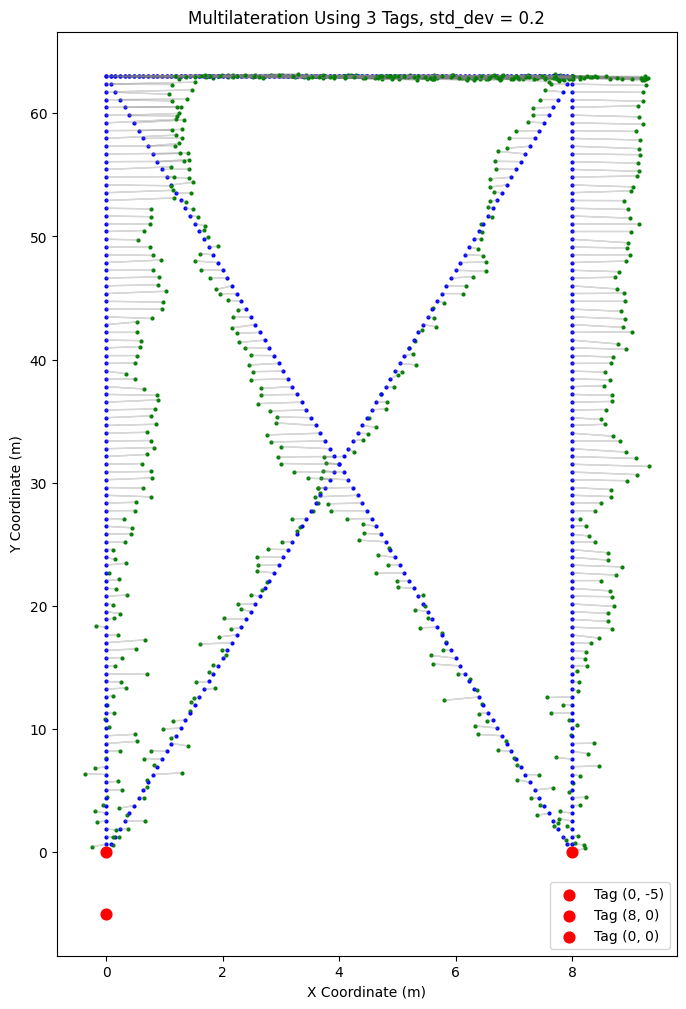

Multilateration Using 3 Tags, std_dev = 0.2

✅ Total Points: 600
📊 Mean Error     = 0.9067 m
📈 Max Error      = 2.4354 m
📉 Std Deviation  = 0.7054 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [0, 20) m 的情況
  數量: 159
  ➤ 平均誤差: 0.9688 m
  ➤ 最大誤差: 2.2645 m
  ➤ 誤差標準差: 0.7905 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [20, 40) m 的情況
  數量: 160
  ➤ 平均誤差: 0.5590 m
  ➤ 最大誤差: 1.6063 m
  ➤ 誤差標準差: 0.3847 m

📌 Anchor 與點 (np.int64(4), np.int64(0)) 距離在 [40, 90) m 的情況
  數量: 281
  ➤ 平均誤差: 1.0695 m
  ➤ 最大誤差: 2.4354 m
  ➤ 誤差標準差: 0.7260 m


In [31]:
tag_position = {(0, 0), (0, -5), (8, 0)}  
# tag_position = {(0, 0),  (8, 0)}

mean = 0
std_dev = 0.2
anchor2tag_distance = {}
anchor2tag_distance_noisy = {}



# --------------------
# 新增：ESP32三點定位演算法 (Python版)
# --------------------
def error_function(x, anchors, distances):
    error = 0.0
    for i in range(len(anchors)):
        dist = np.linalg.norm(x - anchors[i])
        error += (dist - distances[i]) ** 2
    return error

def gps_solve(anchors, distances, initial_guess=np.zeros(2), tol=1e-4, max_iter=200):
    x = initial_guess
    alpha = 0.01  # learning rate
    for _ in range(max_iter):
        grad = np.zeros(2)
        h = 1e-6
        for d in range(2):
            x1 = np.copy(x)
            x2 = np.copy(x)
            x1[d] += h
            x2[d] -= h
            grad[d] = (error_function(x1, anchors, distances) - error_function(x2, anchors, distances)) / (2 * h)
        x_new = x - alpha * grad
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x


# --------------------
# 使用 ESP32 三點演算法做 trilateration 模擬
# --------------------
tag_list = list(tag_position)
true_positions = []
est_positions = []
errors_gps = []

from itertools import product


#----- 距離點模擬： grid_points --------
# 設定場地範圍與密度
# ----------- 替代 grid_points 的生成方式（模仿 anchor 排列） -----------
grid_points = []

# 斜線部分：對角線與反對角線
for i in range(100):
    x = i * 0.08
    y_diag = x * (63 / 8)          # 對角線
    grid_points.append((x, y_diag))

# 水平線上緣
for i in range(100):
    x = 8 - i * 0.08
    grid_points.append((x, 63))

# 斜線部分：對角線與反對角線
for i in range(100):
    x = i * 0.08
    y_anti = 63 - x * (63 / 8)     # 反對角線
    grid_points.append((x, y_anti))

# 垂直線：左、中、右
for i in range(100):
    y = i * 0.63
    grid_points.append((8, y))
# 水平線上緣
for i in range(100):
    x = 8 - i * 0.08
    grid_points.append((x, 63))

# 垂直線：左、中、右
for i in range(100):
    y =63 - i * 0.63
    grid_points.append((0, y))





#----- 距離點模擬： X shape --------
# 會造成很大的誤差，可能是因 gps_solve 的初始值是由上一個點的估計值決定
# 而 X 形狀的點的排序不是照著一直線排序
# grid_points = list(set([tuple(pt) for pt in anchors_position]))



plt.figure(figsize=(8, 12))
plt.title(f"Multilateration Using {len(tag_list)} Tags, std_dev = {std_dev}")
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")

errors = []
prev_est = np.array([4.0, 0])  # 或 (0,0) 看你場地範圍

for point in grid_points:
    point_vec = np.array(point)
    
    # simulate distance from this unknown point to 3 tags
    anchors = [np.array(p) for p in tag_position]
    true_distances = [np.linalg.norm(point_vec - tag) for tag in anchors]
    
    # add gaussian noise
    noisy_distances = [d + np.random.normal(0, 0.2) for d in true_distances]
    
    # estimate this point using gps_solve
     # 使用上一次的結果作為初始值
    est = gps_solve(anchors, noisy_distances, initial_guess=prev_est)
    prev_est = est.copy()  # 儲存這次結果作為下一次的初始值
    error = np.linalg.norm(est - point_vec)
    errors.append(error)
    
    # 畫點與誤差向量
    plt.scatter(est[0], est[1], color='green', s=4)
    plt.scatter(point_vec[0], point_vec[1], color='blue', s=4)
    plt.arrow(point_vec[0], point_vec[1], est[0]-point_vec[0], est[1]-point_vec[1], 
              color='gray', width=0.002, alpha=0.3, length_includes_head=True)

# 畫出 tag 位置
for tag in tag_position:
    plt.scatter(*tag, color='red', s=60, label=f'Tag {tag}')

plt.legend()
plt.show()

errors = np.array(errors)
print(f"Multilateration Using {len(tag_list)} Tags, std_dev = {std_dev}")
print(f"\n✅ Total Points: {len(errors)}")
print(f"📊 Mean Error     = {np.mean(errors):.4f} m")
print(f"📈 Max Error      = {np.max(errors):.4f} m")
print(f"📉 Std Deviation  = {np.std(errors):.4f} m")




for r_min, r_max in ranges:
    indices = np.where((anchor_distances_to_center >= r_min) & (anchor_distances_to_center < r_max))[0]
    if len(indices) == 0:
        print(f"\n⛔ 距離範圍 {r_min}-{r_max} m 沒有 anchor 被選中")
        continue

    range_errors = errors[indices]

    print(f"\n📌 Anchor 與點 {tuple(center_point)} 距離在 [{r_min}, {r_max}) m 的情況")
    print(f"  數量: {len(indices)}")
    print(f"  ➤ 平均誤差: {np.mean(range_errors):.4f} m")
    print(f"  ➤ 最大誤差: {np.max(range_errors):.4f} m")
    print(f"  ➤ 誤差標準差: {np.std(range_errors):.4f} m")
